In [365]:
#-----------  imports
import os
from pathlib import Path
import sys

# data
import numpy as np
import pandas as pd
import xarray as xr
import csv
import netCDF4 as nc

# plots
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import cartopy.crs as ccrs 
import cartopy.feature as cfeature
import cmocean

# image processing
from skimage import feature, filters
import cv2

# ML
from skfda.ml.clustering import KMeans
from skfda.representation import FDataGrid
from scipy.stats import gaussian_kde
    
import re
import gc
import pywt
import mat73

from mpl_toolkits.axes_grid1 import make_axes_locatable

In [366]:
path_2018 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2018_38kHz_bspline_fpca.nc"
path_2021 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2021_38kHz_bspline_fpca.nc"
path_20211 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2021_transect_38kHz_bspline_fpca.nc"
path_2022 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2022_38kHz_bspline_fpca.nc"
path_2023 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2023_38kHz_bspline_fpca.nc"
path_2026 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2026_38kHz_bspline_fpca.nc"
path_temp_2018 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/raw/temp_sal/cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao-so_50.00E-80.00E_60.00S-40.00S_0.49-5727.92m_2018-01-09-2018-02-01_cropped.nc"
path_temp_2021 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/raw/temp_sal/cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao-so_50.00E-80.00E_60.00S-40.00S_0.49-5727.92m_2021-01-13-2021-03-04_cropped.nc"
path_temp_2022 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/raw/temp_sal/cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao-so_50.00E-80.00E_60.00S-40.00S_0.49-5727.92m_2022-02-03-2022-03-03_cropped.nc"
path_temp_2023 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/raw/temp_sal/cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao-so_50.00E-80.00E_60.00S-40.00S_0.49-5727.92m_2023-01-27-2023-02-26.nc_cropped.nc"
path_temp_2026 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/raw/temp_sal/cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao-so_50.00E-80.00E_60.00S-40.00S_0.49-5727.92m_2026-01-14-2026-02-25_cropped.nc"

path_out = "/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute"
path_bathy = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/env/GLO-MFC_001_030_mask_bathy.nc"

In [367]:
PATHS = {
    2018: path_2018,
    2021: path_2021,
    20211 : path_20211,
    2022: path_2022,
    2023: path_2023,
    2026: path_2026,
}

PATHS_TEMP = {
    2018: path_temp_2018,
    2021: path_temp_2021,
    20211 : path_temp_2021,
    2022: path_temp_2022,
    2023: path_temp_2023,
    2026: path_temp_2026,
}

# ── Sélection mission ─────────────────────────────────────────────────────────
MISSION = 20211

path_in   = PATHS[MISSION]
path_temp = PATHS_TEMP[MISSION]
freq=38

In [368]:
with xr.open_dataset(path_in) as ds : 
    print (ds.var)
    print(ds["day"])

<bound method DatasetAggregations.var of <xarray.Dataset> Size: 495MB
Dimensions:              (time: 73610, depth: 491, bspline_k: 50, knot: 54,
                          fpca_component: 50)
Coordinates:
  * time                 (time) datetime64[ns] 589kB 2021-02-07T07:59:22.4067...
  * depth                (depth) float64 4kB 15.0 17.0 19.0 ... 993.0 995.0
  * bspline_k            (bspline_k) int32 200B 0 1 2 3 4 5 ... 45 46 47 48 49
  * knot                 (knot) int32 216B 0 1 2 3 4 5 6 ... 48 49 50 51 52 53
  * fpca_component       (fpca_component) int32 200B 0 1 2 3 4 ... 46 47 48 49
Data variables: (12/16)
    Sv                   (time, depth) float32 145MB ...
    Sv_reconstructed     (time, depth) float64 289MB ...
    bspline_coeffs       (time, bspline_k) float64 29MB ...
    bspline_knots        (knot) float64 432B ...
    day                  (time) int8 74kB ...
    latitude             (time) float64 589kB ...
    ...                   ...
    fpca_var_ratio       (fp

In [369]:
def create_path_figure(folder_comp, title, path_in=path_in, path_out=path_out) : 
    dataset_name = Path(path_in).stem
    save_dir = Path(path_out) / folder_comp
    save_dir.mkdir(parents=True, exist_ok=True)
    path = os.path.join(save_dir, f"{dataset_name}_{title}.png")
    return path

# verification des projections

In [370]:
def compare_sv_original_bspline_reconstructed(path_in=path_in, path_out=path_out, save=False) : 
    ds = xr.open_dataset(path_in)
    sv_original = ds["Sv"].values
    sv_rec = ds["Sv_reconstructed"].values
    print(sv_original.shape, ds["Sv"].values.shape, sv_rec.shape)

    depth = ds["depth"]
    ping_indices = [0, 200, 400, 600, 800]

    fig, axes = plt.subplots(1, len(ping_indices),
                            figsize=(4 * len(ping_indices), 8),
                            sharey=True)
    fig.suptitle(f"Reconstruction Bspline vs signal original", fontsize=13)

    for col, ping_idx in enumerate(ping_indices):
        ax = axes[col]

        original = sv_original[ping_idx]
        rec = sv_rec[ping_idx]
        ax.plot(original, depth, color="black", linewidth=1.2,
                label="Sv (dB re 1m-1) original", zorder=5)

        
        ax.plot(rec, depth, color="red", linewidth=0.8, alpha=0.8,
                    label=f"Sv (dB re m-1) reconstructed Bsplines")

        ax.set_title(f"ping {ping_idx}", fontsize=10)
        ax.set_xlabel("Sv (dB re 1m-1)", fontsize=9)
        ax.invert_yaxis()
        ax.legend(fontsize=8, loc="lower right")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("profondeur (m)", fontsize=9)   # ylabel une seule fois à gauche
    plt.tight_layout()
    if save : 
        path = create_path_figure("reconstruction_Bspline", "reconstruction_bspline", path_in=path_in)
        print(path)
        plt.savefig(path)
    else : 
        plt.show()

(73610, 491) (73610, 491) (73610, 491)


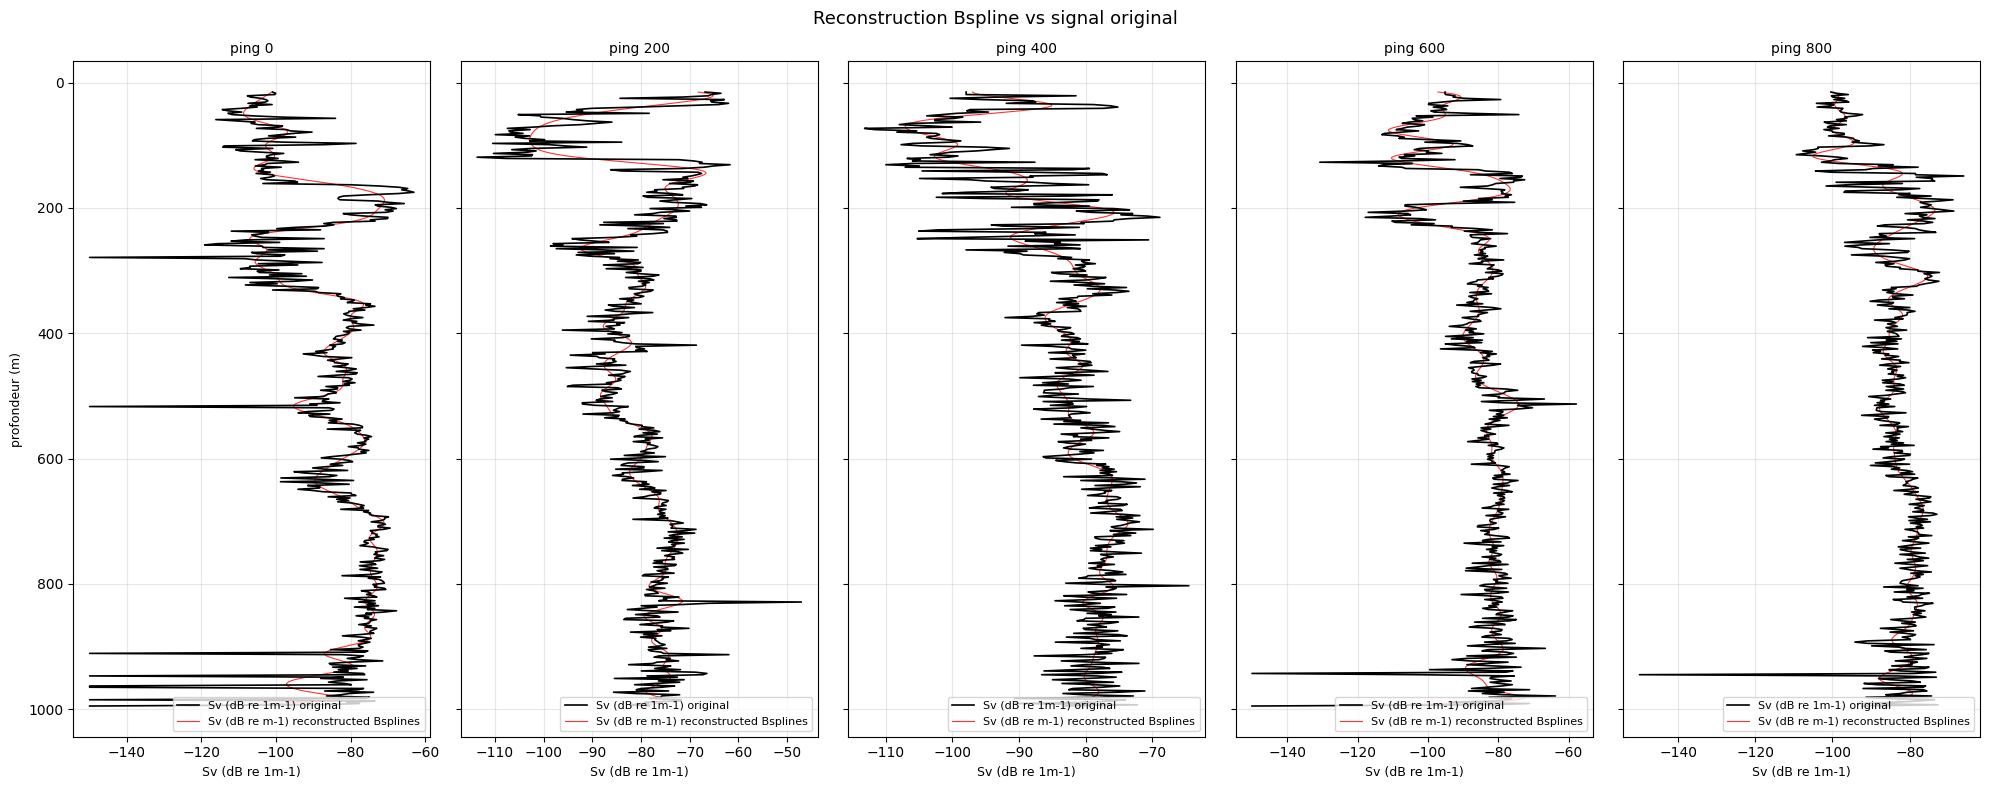

In [371]:
compare_sv_original_bspline_reconstructed()

In [372]:
def plot_echogram_comparison(day_idx=0, path_in=path_in, path_out=path_out, save=False):
    ds = xr.open_dataset(path_in)
    dataset_name = Path(path_in).stem
    times = pd.DatetimeIndex(ds["time"].values)
    # print(times)
    dates = np.unique(times.date)
    # print(dates.shape, dates)
    target_day = dates[day_idx]
    mask = times.date == target_day
    
    sv_original = ds["Sv"].values[mask, :]
    sv_rec      = ds["Sv_reconstructed"].values[mask, :]
    depth       = ds["depth"].values
    time_day    = times[mask]  # timestamps du jour sélectionné
    
    # print(f"Jour : {target_day} — {mask.sum()} pings")
    ds.close()
    
    vmin, vmax = np.nanpercentile(sv_original, [2, 98])
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=True)
    fig.suptitle(f"Echogramme {dataset_name} — {target_day}", fontsize=13)
    
    for ax, data, title in zip(axes,
                                [sv_original, sv_rec],
                                ["Sv original", "Sv reconstructed (Bspline)"]):
        im = ax.pcolormesh(
            time_day,       # ← timestamps en x au lieu de np.arange(...)
            depth,
            data.T,
            cmap="plasma",
            vmin=vmin, vmax=vmax,
            shading="auto"
        )
        ax.set_title(title, fontsize=11)
        ax.set_ylabel("Profondeur (m)", fontsize=9)
        fig.colorbar(im, ax=ax, label="Sv (dB re 1m-1)", pad=0.01)
    
    ax.invert_yaxis()
    
    # Formatage de l'axe temporel
    locator   = mdates.AutoDateLocator()
    formatter = mdates.DateFormatter("%H:%M")
    axes[-1].xaxis.set_major_locator(locator)
    axes[-1].xaxis.set_major_formatter(formatter)
    fig.autofmt_xdate(rotation=30, ha="right")
    axes[-1].set_xlabel("Heure (UTC)", fontsize=9)
    
    plt.tight_layout()
    
    if save : 
        path = create_path_figure("reconstruction_Bspline", "echogram_comparison_bspline", path_in=path_in)
        print(path)
        plt.savefig(path)
    else : 
        plt.show()

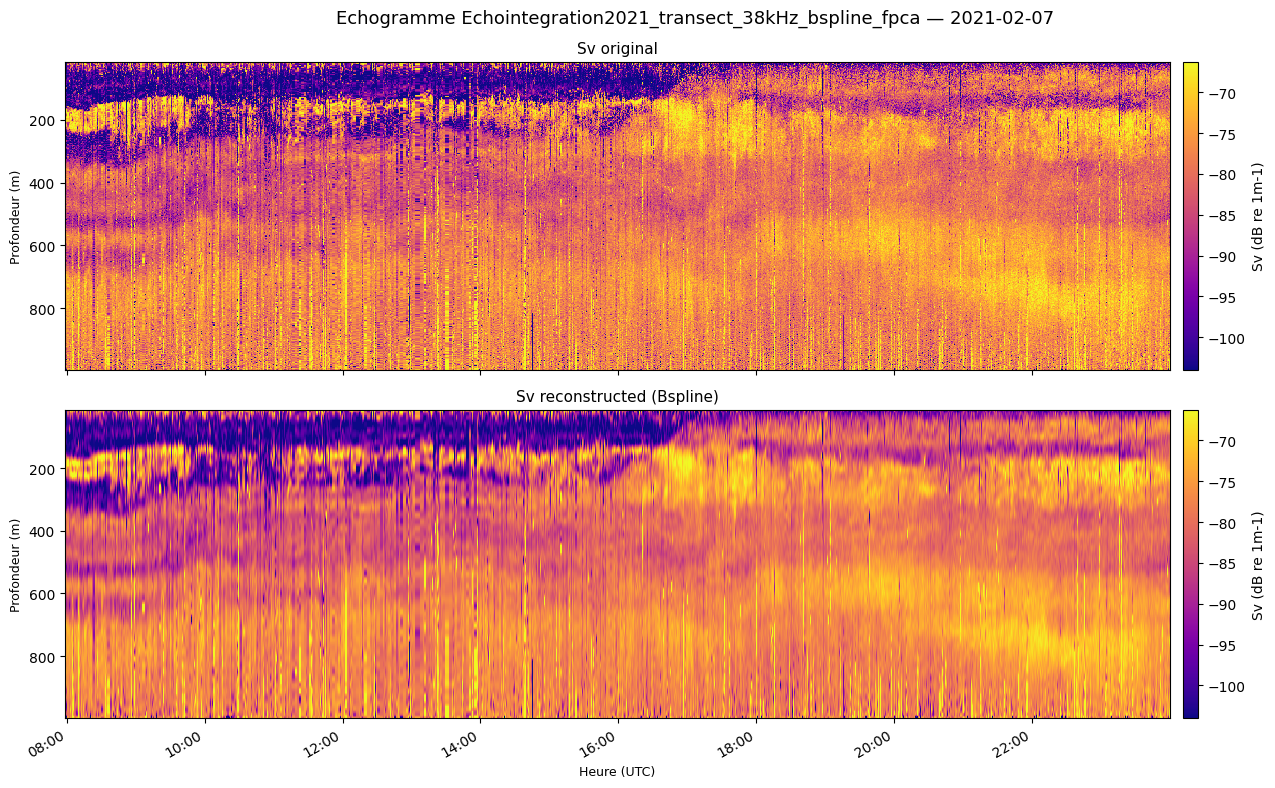

In [373]:
plot_echogram_comparison()

In [380]:
def plot_echogram(path_in=path_in, day=None, freq=38, freq_s="8s", title=None,
                  vmin=-100, vmax=-60, cmap="plasma", path_out=path_out, save=False):

    # ── chargement ────────────────────────────────────────────────────────────
    ds       = xr.open_dataset(path_in)
    time_all = pd.to_datetime(ds["time"].values).floor("s")
    sv_all   = ds["Sv"].values        # (n_pings, depth)
    depth    = ds["depth"].values
    ds.close()

    # ── liste des jours à tracer ──────────────────────────────────────────────
    if day is None:
        days = pd.to_datetime(time_all.normalize()).unique()
    else:
        days = [pd.Timestamp(day).date()]

    print(f"  {len(days)} jour(s) à tracer")

    for d in days:
        d    = pd.Timestamp(d).date()
        mask = np.array([t.date() == d for t in time_all])
        if not mask.any():
            print(f"  [!] Aucun ping pour {d}, ignoré.")
            continue

        time    = time_all[mask]
        sv      = sv_all[mask, :]
        day_str = pd.Timestamp(d).strftime("%Y-%m-%d")
        print(f"  → {day_str}  ({mask.sum()} pings)")

        # ── grille régulière ──────────────────────────────────────────────────
        time_start   = time[0].floor(freq_s)
        time_end     = time[-1].ceil(freq_s)
        time_regular = pd.date_range(start=time_start, end=time_end, freq=freq_s)

        time_numeric         = time.astype(np.int64)
        time_regular_numeric = time_regular.astype(np.int64)

        idx_left  = np.searchsorted(time_regular_numeric, time_numeric, side="left")
        idx_left  = np.clip(idx_left, 0, len(time_regular) - 1)
        idx_right = np.clip(idx_left - 1, 0, len(time_regular) - 1)

        diff_left  = np.abs(time_regular_numeric[idx_left]  - time_numeric)
        diff_right = np.abs(time_regular_numeric[idx_right] - time_numeric)
        indices    = np.where(diff_left <= diff_right, idx_left, idx_right)

        sv_regular = np.full((len(time_regular), sv.shape[1]), np.nan)
        used       = np.zeros(len(time_regular), dtype=bool)
        for i, idx in enumerate(indices):
            if not used[idx]:
                sv_regular[idx] = sv[i]
                used[idx]       = True

        # ── plot ──────────────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(14, 5))
        img = ax.pcolormesh(
            time_regular.values, depth, sv_regular.T,
            shading="auto", cmap=cmap, vmin=vmin, vmax=vmax,
        )
        cbar = fig.colorbar(img, ax=ax, pad=0.01, fraction=0.02)
        cbar.set_label("Sv (dB re 1 m⁻¹)", fontsize=11)
        ax.invert_yaxis()
        ax.set_ylabel("Profondeur (m)", fontsize=11)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
        ax.set_xlabel("Heure (UTC)", fontsize=11)
        ax.set_title(title if title else f"Échogramme — {day_str} — {freq} Hz")
        plt.tight_layout()

        if save:
            path = create_path_figure(
                f"echograms_per_day/{freq}",
                f"echogram_{day_str}",
                path_in=path_in,
            )
            print(f"    {path}")
            plt.savefig(path, bbox_inches="tight")
            plt.close()
        else:
            plt.show()

In [381]:
plot_echogram(path_in=path_in, freq=freq, save=True)

  25 jour(s) à tracer
  → 2021-02-07  (2886 pings)
    /home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/echograms_per_day/38/Echointegration2021_transect_38kHz_bspline_fpca_echogram_2021-02-07.png
  → 2021-02-08  (4843 pings)
    /home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/echograms_per_day/38/Echointegration2021_transect_38kHz_bspline_fpca_echogram_2021-02-08.png
  → 2021-02-09  (1127 pings)
    /home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/echograms_per_day/38/Echointegration2021_transect_38kHz_bspline_fpca_echogram_2021-02-09.png
  → 2021-02-10  (5124 pings)
    /home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/echograms_per_day/38/Echointegration2021_transect_38kHz_bspline_fpca_echogram_2021-02-10.png
  → 2021-02-11  (3198 pings)
    /home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/echograms_per_day/38/Echointegration2021_transect_3

In [374]:
def plot_profile(freq, year, path_in=path_in, path_out=path_out, save=False):
    ds     = xr.open_dataset(path_in)
    idx=0
    depth = ds["depth"].values
    sv_rec      = ds["Sv_reconstructed"].values
    sv = ds["Sv"].values
    K = ds.attrs["bspline_K"]
    lambd = ds.attrs["bspline_lambda"]
    times = pd.DatetimeIndex(ds["time"].values)
    ds.close()
    dataset_name = Path(path_in).stem
    n_pings = sv_rec.shape[0]
    
    
    for idx in range(n_pings) :
        fig, ax = plt.subplots(figsize=(4, 7))
        ax.plot(sv[idx, :], depth, "k-",  lw=1.5, label="original")
        
        ax.plot(sv_rec[idx, :], depth, "r--", lw=1.5, label=f"B-spline K={K} λ={lambd}")
        ax.invert_yaxis()
        ax.set_xlabel("Sv (dB)"); ax.set_ylabel("Depth (m)")
        ax.set_title(f"{dataset_name} ping {idx} {times[idx].round("s")}")
        ax.legend(); ax.grid(alpha=0.3)
        plt.tight_layout()
        if save:
            path = create_path_figure(
                f"reconstruction_Bspline/ping_rec/{year}/{freq}",
                f"ping_{idx}_{times[idx]}",
                path_in=path_in,
            )
            print(path)
            plt.savefig(path)
            plt.close()
        else:
            plt.show()

/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/reconstruction_Bspline/ping_rec/20211/38/Echointegration2021_transect_38kHz_bspline_fpca_ping_0_2021-02-07 07:59:22.406704896.png
/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/reconstruction_Bspline/ping_rec/20211/38/Echointegration2021_transect_38kHz_bspline_fpca_ping_1_2021-02-07 08:01:35.181603328.png
/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/reconstruction_Bspline/ping_rec/20211/38/Echointegration2021_transect_38kHz_bspline_fpca_ping_2_2021-02-07 08:01:42.165602816.png
/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/reconstruction_Bspline/ping_rec/20211/38/Echointegration2021_transect_38kHz_bspline_fpca_ping_3_2021-02-07 08:02:38.305109248.png
/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/reconstruction_Bspline/ping_rec/20211/38/Echointegration2021_transect_38kHz_bspline_fpca_p

KeyboardInterrupt: 

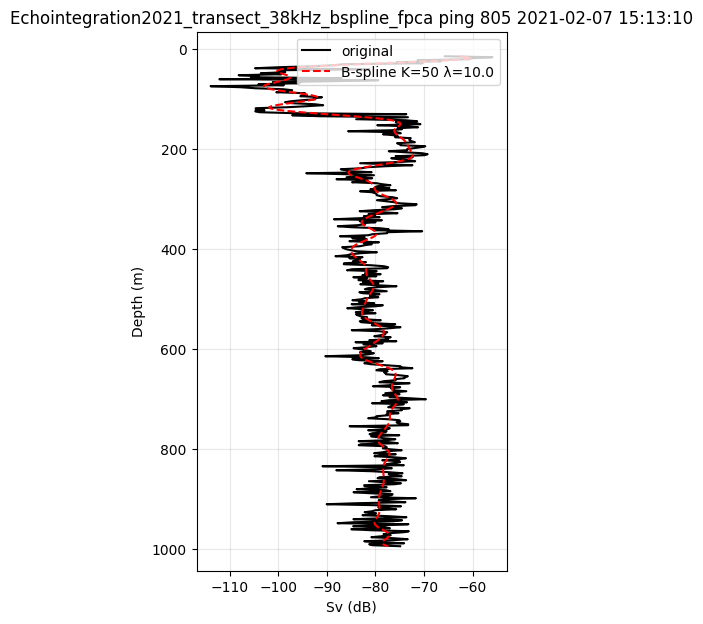

In [375]:
plot_profile(freq, MISSION, save=True)

# Bspline & fpca

In [ ]:
# from scipy.interpolate import BSpline
# import scipy.linalg as la

# freq_idx = 1   # 18kHz

# with xr.open_dataset(path_in) as ds : 
#     sv = ds["Sv"].values[freq_idx, :, :]
#     depth = ds["depth"].values  # n_depths,
#     n_pings, n_depths = sv.shape

#     # gestion des nans 
#     nan_ratio = np.isnan(sv).mean(axis=1)        # (n_pings,) — ratio NaN par profil
#     mask      = nan_ratio < 0.20                  # garder < 20% de NaN
#     sv  = sv[mask]
#     for i in range(sv.shape[0]):
#         row  = sv[i]
#         nans = np.isnan(row)
#         if nans.any():
#             x = np.where(~nans)[0]
#             sv[i, nans] = np.interp(np.where(nans)[0], x, row[x])

#     # estimation fonctionelle

#     K = 50
#     r = 4
#     lambd = 10

#     knots = np.concatenate([
#         np.repeat(depth[0],  r),                        # 4 noeuds au début
#         np.linspace(depth[0], depth[-1], K - r + 2)[1:-1],  # noeuds intérieurs seulement
#         np.repeat(depth[-1], r)                         # 4 noeuds à la fin
#     ])

#     # Vérification
#     phi = np.zeros((n_depths, K))
#     for k in range(K):
#         c = np.zeros(K); c[k] = 1.0
#         phi[:, k] = BSpline(knots, c, r - 1)(depth)
        
#     # terme de penalisation 
#     n_quad = 10_000
#     z_quad = np.linspace(depth[0], depth[-1], n_quad)
#     dz     = z_quad[1] - z_quad[0]
#     D2     = np.zeros((n_quad, K))
#     for k in range(K):
#         c = np.zeros(K); c[k] = 1.0
#         D2[:, k] = BSpline(knots, c, r - 1).derivative(2)(z_quad)
#     R = D2.T @ D2 * dz   # (K × K)
   
#     A     = phi.T @ phi + lambd * R          # (K × K)
#     rhs   = phi.T @ sv.T                     # (K × n_pings)
#     coefs = la.solve(A, rhs, assume_a="pos") # (K × n_pings)
#     coefs = coefs.T
#     idx = 10
#     sv_rec = phi @ coefs[idx]   # (n_depths,)

#     fig, ax = plt.subplots(figsize=(4, 7))
#     ax.plot(sv[idx], depth, "k-",  lw=1.5, label="original")
#     ax.plot(sv_rec,        depth, "r--", lw=1.5, label=f"B-spline K={K} λ={lambd}")
#     ax.invert_yaxis()
#     ax.set_xlabel("Sv (dB)"); ax.set_ylabel("Depth (m)")
#     ax.set_title(f"ping {idx}")
#     ax.legend(); ax.grid(alpha=0.3)
#     plt.tight_layout()
#     plt.show()
#     # ----------------- get phi
#     phi = np.zeros((n_depths, K)) # n_depths, K
#     for k in range(K):
#         c = np.zeros(K); c[k] = 1.0 # vecteur de taille K avec 1 à la position k (one hot)
#         phi[:, k] = BSpline(knots, c, r - 1)(depth) # matrice de base B-spline évaluée sur la grille de profondeur
    

#     #-----------------  get mat centrée C
#     coeffs_moy = np.nanmean(coefs, axis=0)
#     C = coefs - coeffs_moy # n_pings, K
#     covar = 1/n_pings * C.T @ C # K, K

#     # ----------------- get matrice de gram W[j,k] = ∫ B_j(z) · B_k(z) dz 
#     # Quadrature numérique sur une grille fine (équivalent eval.penalty en R)
#     n_quad  = 10_000
#     z_quad  = np.linspace(depth[0], depth[-1], n_quad)
#     dz      = z_quad[1] - z_quad[0]

#     # phi_quad : (n_quad, K) — bases évaluées sur la grille fine
#     phi_quad = np.zeros((n_quad, K))
#     for k in range(K):
#         c = np.zeros(K); c[k] = 1.0
#         phi_quad[:, k] = BSpline(knots, c, r - 1)(z_quad)

#     W = phi_quad.T @ phi_quad * dz   # (K × K)  ≈  ∫ B_j · B_k dz

#     # Symétrie explicite (équivalent W <- (W + t(W))/2)
#     W = (W + W.T) / 2

#     # ── Cholesky : W = Wdem.T @ Wdem  (Wdem = W^{1/2} triangulaire supérieure) ──
#     # Note : scipy chol donne L triangulaire inférieure, R donne U supérieure
#     # R : Wdem <- chol(W)        → W = Wdem.T @ Wdem  (upper)
#     # scipy : la.cholesky(W)     → W = L @ L.T         (lower, défaut)
#     # Pour reproduire R : upper=True
#     Wdem    = la.cholesky(W, lower=False)    # (K × K) triangulaire supérieure = R's chol(W)

#     # ── W^{-1/2} : solve(Wdem) ───────────────────────────────────────────────────
#     Wdeminv = la.solve_triangular(Wdem, np.eye(K), lower=False)   # plus stable que np.linalg.inv

#     # VWM
#     covarW = Wdem @ covar @ Wdem.T

#     # fpca <- eigen(covarW)
#     eigenvalues, eigenvectors = la.eigh(covarW)          # eigh car symétrique
#     idx          = np.argsort(eigenvalues)[::-1]     # ordre décroissant
#     eigenvalues  = eigenvalues[idx]
#     eigenvectors = eigenvectors[:, idx]

#     # fpca$vectors <- Wdeminv %*% fpca$vectnotWM
#     vectors = Wdeminv @ eigenvectors                 # vecteurs W-normalisés

#     # fpca$axe <- sweep(fpca$vectors, 2, sqrt(fpca$values), "*")
#     axe = vectors * np.sqrt(eigenvalues)[np.newaxis, :]   # déformation ± 1σ

#     # fpca$pc <- C %*% W %*% fpca$vectors
#     pc = C @ W @ vectors                             # scores (n_pings × K)
#     print(pc.shape)
#     # variance expliquée
#     pval = eigenvalues / eigenvalues.sum() * 100

#     plt.scatter(pc[:,0], pc[:, 1])
#     plt.gca().set_xlabel("pc1")
#     plt.gca().set_ylabel("pc2")
#     plt.show()

#     k = 0   # PC1
#     for k in range(5) :

#         mu    = phi @ coeffs_moy          # (n_depths,) — profil moyen
#         axe_k = phi @ axe[:, k]           # (n_depths,) — eigenfunction k

#         fig, ax = plt.subplots(figsize=(4, 7))
#         ax.plot(mu,         depth, "k-",  color="black", lw=2,   label="moyenne")
#         ax.plot(mu + axe_k, depth, "r-",  color="red", lw=1.2, label=f"μ + eigenfunc{k+1}")
#         ax.plot(mu - axe_k, depth, "r--", color="blue", lw=1.2, label=f"μ - eigenfunc{k+1}")
#         ax.invert_yaxis()
#         ax.set_xlabel("Sv (dB)"); ax.set_ylabel("Depth (m)")
#         ax.set_title(f"Eigenfunction {k+1}  ({pval[k]:.1f}% var)")
#         ax.legend(); ax.grid(alpha=0.3)
#         plt.tight_layout()
#         plt.show()

# fpca plots

In [382]:
def plot_eigenfunctions(year, freq, ath_in=path_in, path_out=path_out, save=False) :
    ds = xr.open_dataset(path_in)
    scores  = ds["fpca_scores"].values          # (n_pings, K)
    mu      = ds["fpca_mean_profile"].values    # (depth,)
    axe     = ds["fpca_axe"].values             # (bspline_k, fpca_component)  — déformation ±1σ
    eigfunc = ds["fpca_eigenfunctions"].values  # (depth, fpca_component)       — phi @ vectors
    pval    = ds["fpca_var_ratio"].values * 100 # (K,) en %
    depth   = ds["depth"].values
    eigenvalues = ds["fpca_eigenvalues"].values
    cum_var = ds["fpca_cumulative_var"].values
    ds.close()

    # ── Scatter PC1 / PC2 ────────────────────────────────────────────────────────
    plt.scatter(scores[:, 0], scores[:, 1], s=2)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Scores FPCA")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    if save:
        path = create_path_figure(
            f"fpca/pc1_pc2/",
            f"pc1_pc2",
            path_in=path_in,
        )
        print(path)
        plt.savefig(path)
        plt.close()
    else:
        plt.show()

    # ── Eigenfunctions ───────────────────────────────────────────────────────────
    K = np.argmax(cum_var >= 0.9) + 1

    for k in range(K):
        axe_k = eigfunc[:, k] * np.sqrt(eigenvalues[k])   # ← déformation ±1σ

        fig, ax = plt.subplots(figsize=(4, 7))
        ax.plot(mu,          depth, color="black", lw=2,   label="moyenne")
        ax.plot(mu + axe_k,  depth, color="red",   lw=1.2, label=f"μ + √λ·ξ{k+1}")
        ax.plot(mu - axe_k,  depth, color="blue",  lw=1.2, label=f"μ - √λ·ξ{k+1}")      
        ax.invert_yaxis()
        ax.set_xlabel("Sv (dB)")
        ax.set_ylabel("Depth (m)")
        ax.set_title(f"Eigenfunction {k+1}  ({pval[k]:.1f}% var, {cum_var[k]*100:.1f}%)")
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        if save:
            path = create_path_figure(
                f"fpca/eigenfunction/{year}/{freq}",
                f"eigenfunction_{k}",
                path_in=path_in,
            )
            print(path)
            plt.savefig(path)
            plt.close()
        else:
            plt.show()

    # ── Subplots — toutes les eigenfunctions ─────────────────────────────────
    ncols = 5
    nrows = int(np.ceil(K / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 7 * nrows))
    axes = axes.flatten()

    for k in range(K):
        axe_k = eigfunc[:, k] * np.sqrt(eigenvalues[k])
        ax = axes[k]
        ax.plot(mu,           depth, color="black", lw=2,   label="moyenne")
        ax.plot(mu + axe_k,   depth, color="red",   lw=1.2, label=f"μ + √λ·ξ{k+1}")
        ax.plot(mu - axe_k,   depth, color="blue",  lw=1.2, label=f"μ - √λ·ξ{k+1}")
        ax.invert_yaxis()
        ax.set_xlabel("Sv (dB)")
        ax.set_ylabel("Depth (m)")
        ax.set_title(
            f"PC{k+1}  —  λ={eigenvalues[k]:.2f}\n"
            f"({pval[k]:.1f}% var,  cumulé {cum_var[k]*100:.1f}%)"
        )
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    # masquer les axes vides si K n'est pas multiple de ncols
    for k in range(K, len(axes)):
        axes[k].set_visible(False)

    fig.suptitle(f"Eigenfunctions FPCA — {year} {freq}Hz", fontsize=14, y=1.01)
    plt.tight_layout()
    if save:
        path = create_path_figure(
            f"fpca/eigenfunction",
            f"eigenfunctions_all",
            path_in=path_in,
        )
        print(path)
        plt.savefig(path, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

In [383]:
plot_eigenfunctions(MISSION, freq, save=True)

/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca/pc1_pc2/Echointegration2021_transect_38kHz_bspline_fpca_pc1_pc2.png
/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca/eigenfunction/20211/38/Echointegration2021_transect_38kHz_bspline_fpca_eigenfunction_0.png
/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca/eigenfunction/20211/38/Echointegration2021_transect_38kHz_bspline_fpca_eigenfunction_1.png
/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca/eigenfunction/20211/38/Echointegration2021_transect_38kHz_bspline_fpca_eigenfunction_2.png
/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca/eigenfunction/20211/38/Echointegration2021_transect_38kHz_bspline_fpca_eigenfunction_3.png
/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca/eigenfunction/20211/38/Echointegration2021_transect_38kHz_bspline_fpca

In [ ]:
def plot_fpca_reconstruction(freq, ping_indices=None, path_in=path_in, path_out=path_out, save=False):
    ds = xr.open_dataset(path_in)
    dataset_name = Path(path_in).stem
    scores      = ds["fpca_scores"].values
    mu          = ds["fpca_mean_profile"].values
    eigfunc     = ds["fpca_eigenfunctions"].values
    pval        = ds["fpca_var_ratio"].values * 100
    depth       = ds["depth"].values
    eigenvalues = ds["fpca_eigenvalues"].values
    cum_var     = ds["fpca_cumulative_var"].values
    sv_rec      = ds["Sv_reconstructed"].values
    ds.close()

    if eigfunc.shape[0] != len(depth):
        eigfunc = eigfunc.T

    K_max    = np.argmax(cum_var >= 0.9) + 1
    K_values = list(range(1, K_max + 1))
    cmap     = plt.cm.get_cmap("plasma", len(K_values))
    colors   = [cmap(i) for i in range(len(K_values))]

    if ping_indices is None:
        n_pings      = sv_rec.shape[0]
        ping_indices = np.linspace(0, n_pings - 1, 5, dtype=int).tolist()

    n_cols = len(ping_indices)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 7), sharey=True, sharex=True)
    if n_cols == 1:
        axes = [axes]

    for col, idx_c in enumerate(ping_indices):
        ax = axes[col]

        # signal original
        ax.plot(sv_rec[idx_c, :], depth,
                color="black", linewidth=1.4, label="original", zorder=10)

        # reconstructions K=1..K_max
        for K_val, color in zip(K_values, colors):
            rec = mu + scores[idx_c, :K_val] @ eigfunc[:, :K_val].T
            ax.plot(rec, depth, color=color, linewidth=0.9, alpha=0.85,
                    label=f"K={K_val}  ({cum_var[K_val-1]*100:.1f}%)")  # ← variance cumulée jusqu'à K

        ax.set_title(f"ping {idx_c}", fontsize=10)
        ax.set_xlabel("Sv (dB)", fontsize=9)
        ax.legend(fontsize=7, loc="lower right")
        ax.grid(True, alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)
        ax.invert_yaxis()

    axes[0].set_ylabel("Depth (m)", fontsize=9)
    fig.suptitle(
        f"{dataset_name} — {freq} Hz — Reconstruction FPCA\n"
        f"K={K_max} PCs → {cum_var[K_max-1]*100:.1f}% var. expliquée",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()

    if save:
        path = create_path_figure(
            f"fpca/reconstruction_profile",
            f"reconstruction_profile_fpca",
            path_in=path_in,
        )
        print(path)
        plt.savefig(path, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

In [ ]:
plot_fpca_reconstruction(freq, save=True)

/tmp/ipykernel_8906/2683642171.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap     = plt.cm.get_cmap("plasma", len(K_values))


/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca/reconstruction_profile/Echointegration2026_38kHz_bspline_fpca_reconstruction_profile_fpca.png


In [384]:
def plot_scores_traj(freq, cp, path_in=path_in, path_out=path_out, save=False):
    ds = xr.open_dataset(path_in)
    dataset_name = Path(path_in).stem
    scores      = ds["fpca_scores"].values          # (n_pings, K)
    day_phase   = ds["day"].values
    depth       = ds["depth"].values
    eigfunc     = ds["fpca_eigenfunctions"].values  # (depth, K)
    eigenvalues = ds["fpca_eigenvalues"].values     # (K,)
    var_ratio   = ds["fpca_var_ratio"].values       # (K,)
    mu          = ds["fpca_mean_profile"].values    # (depth,)
    ds.close()

    if eigfunc.shape[0] != len(depth):
        eigfunc = eigfunc.T

    score_cp = scores[:, cp]
    ef       = eigfunc[:, cp]
    std      = np.sqrt(eigenvalues[cp])

    phase_cmap = {
        1: ("#1a1a2e", "Night"),
        2: ("#f4a261", "Sunrise"),
        3: ("#90e0ef", "Day"),
        4: ("#e76f51", "Sunset"),
    }
    GREY, RED, BLUE = "#444444", "#c0392b", "#2166ac"
    n_pings = len(score_cp)

    fig = plt.figure(figsize=(16, 5))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.08)
    ax    = fig.add_subplot(gs[0])
    ax_ef = fig.add_subplot(gs[1])

    # ── Scatter colorié par phase ─────────────────────────────────────────────
    for phase, (color, label) in phase_cmap.items():
        mask = day_phase == phase
        ax.scatter(np.where(mask)[0], score_cp[mask], s=1, color=color, label=label)

    from matplotlib.patches import Patch
    phase_handles = [Patch(color=v[0], label=v[1]) for v in phase_cmap.values()]
    ax.legend(handles=phase_handles, fontsize=8, loc="upper right",
              ncol=4, framealpha=0.8, markerscale=3)
    ax.set_xlim(0, n_pings)
    ax.set_xlabel("Ping index", fontsize=9)
    ax.set_ylabel(f"PC{cp+1} score", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, alpha=0.2)

    # ── Eigenfunction ─────────────────────────────────────────────────────────
    ax_ef.plot(mu,            depth, color=GREY, linewidth=2,   label="moyenne",  zorder=3)
    ax_ef.plot(mu + std * ef, depth, color=RED,  linewidth=1.5,
               label=fr"μ + $\sqrt{{\lambda_{{{cp+1}}}}}$·ξ$_{{{cp+1}}}$", zorder=2)
    ax_ef.plot(mu - std * ef, depth, color=BLUE, linewidth=1.5,
               label=fr"μ − $\sqrt{{\lambda_{{{cp+1}}}}}$·ξ$_{{{cp+1}}}$", zorder=2)
    ax_ef.fill_betweenx(depth, mu - std * ef, mu + std * ef,
                        alpha=0.08, color="purple")
    ax_ef.invert_yaxis()
    ax_ef.set_xlabel("Sv (dB)", fontsize=9)
    ax_ef.set_ylabel("Depth (m)", fontsize=9)
    ax_ef.set_title(f"PC{cp+1}  —  λ={eigenvalues[cp]:.2f}\n"
                    f"{var_ratio[cp]*100:.1f}% var. expliquée",
                    fontsize=9, fontweight="bold")
    ax_ef.spines[["top", "right"]].set_visible(False)
    ax_ef.grid(True, alpha=0.2)
    ax_ef.legend(fontsize=7, loc="lower right")

    fig.suptitle(f"PC{cp+1} score by ping", fontsize=11, fontweight="bold", y=1.02)
    fig.text(0.5, 0.97, f"{dataset_name} — {freq} kHz", ha="center", fontsize=9)
    plt.tight_layout()

    if save:
        path = create_path_figure(
            f"fpca/pc_scores_by_ping",
            f"pc{cp+1}_scores",
            path_in=path_in,
        )
        print(path)
        plt.savefig(path, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

In [385]:
for k in range(10) :
    plot_scores_traj(freq, k, save=True)

/tmp/ipykernel_8906/3654736462.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca/pc_scores_by_ping/Echointegration2021_transect_38kHz_bspline_fpca_pc1_scores.png


/tmp/ipykernel_8906/3654736462.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca/pc_scores_by_ping/Echointegration2021_transect_38kHz_bspline_fpca_pc2_scores.png


/tmp/ipykernel_8906/3654736462.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


...

/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca/pc_scores_by_ping/Echointegration2021_transect_38kHz_bspline_fpca_pc8_scores.png


/tmp/ipykernel_8906/3654736462.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca/pc_scores_by_ping/Echointegration2021_transect_38kHz_bspline_fpca_pc9_scores.png


/tmp/ipykernel_8906/3654736462.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca/pc_scores_by_ping/Echointegration2021_transect_38kHz_bspline_fpca_pc10_scores.png


In [ ]:
def plot_fpca_map_with_profile(freq, cp, path_in=path_in, path_env=path_temp, path_out=path_out, save=False):
    ds     = xr.open_dataset(path_in)
    ds_env = xr.open_dataset(path_env)
    dataset_name = Path(path_in).stem

    # ── FPCA ─────────────────────────────────────────────────────────────────
    scores      = ds["fpca_scores"].values          # (n_pings, K)
    lon         = ds["longitude"].values
    lat         = ds["latitude"].values
    depth       = ds["depth"].values
    eigfunc     = ds["fpca_eigenfunctions"].values  # (depth, K)
    eigenvalues = ds["fpca_eigenvalues"].values     # (K,)
    var_ratio   = ds["fpca_var_ratio"].values       # (K,)
    mu          = ds["fpca_mean_profile"].values    # (depth,)
    ds.close()

    if eigfunc.shape[0] != len(depth):
        eigfunc = eigfunc.T

    score_cp = scores[:, cp]
    ef       = eigfunc[:, cp]
    std      = np.sqrt(eigenvalues[cp])

    # ── ENV (température surface) ─────────────────────────────────────────────
    temp      = ds_env["thetao"].sel(depth=0, method="nearest")
    temp_mean = temp.mean("time").values
    lons      = ds_env["longitude"].values
    lats      = ds_env["latitude"].values
    ds_env.close()

    vmin = np.nanpercentile(temp_mean, 2)
    vmax = np.nanpercentile(temp_mean, 98)

    # ── Normalisation scores ──────────────────────────────────────────────────
    norm        = mcolors.Normalize(vmin=np.nanpercentile(score_cp, 2),
                                    vmax=np.nanpercentile(score_cp, 98))
    cmap_scores = cm.plasma

    # ── Figure ───────────────────────────────────────────────────────────────
    GREY, RED, BLUE = "#444444", "#c0392b", "#2166ac"

    fig = plt.figure(figsize=(16, 6))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[3, 1], wspace=0.35)

    # ── Carte ─────────────────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="white")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

    mesh = ax.pcolormesh(lons, lats, temp_mean,
                         cmap="Greys", vmin=vmin, vmax=vmax,
                         transform=ccrs.PlateCarree(), shading="auto", alpha=0.9)

    sc = ax.scatter(lon, lat, c=score_cp, cmap=cmap_scores, norm=norm,
                    s=8, transform=ccrs.PlateCarree(), zorder=3)

    ax.set_title(f"PC{cp+1} — {freq} Hz — Température de surface moyenne", fontsize=10)

    cbar1 = fig.colorbar(mesh, ax=ax, orientation="horizontal",
                         pad=0.04, fraction=0.035, aspect=35, shrink=0.85)
    cbar1.set_label("Température moyenne de surface (°C)", fontsize=9)
    cbar1.ax.tick_params(labelsize=8)

    cbar2 = fig.colorbar(sc, ax=ax, orientation="vertical",
                         pad=0.02, fraction=0.03, aspect=30, shrink=0.85)
    cbar2.set_label(f"Score PC{cp+1}", fontsize=9)
    cbar2.ax.tick_params(labelsize=8)

    # ── Eigenfunction ─────────────────────────────────────────────────────────
    ax_ef = fig.add_subplot(gs[1])
    ax_ef.plot(mu,            depth, color=GREY, linewidth=2,   label="moyenne",  zorder=3)
    ax_ef.plot(mu + std * ef, depth, color=RED,  linewidth=1.5,
               label=fr"μ + $\sqrt{{\lambda_{{{cp+1}}}}}$·ξ$_{{{cp+1}}}$", zorder=2)
    ax_ef.plot(mu - std * ef, depth, color=BLUE, linewidth=1.5,
               label=fr"μ − $\sqrt{{\lambda_{{{cp+1}}}}}$·ξ$_{{{cp+1}}}$", zorder=2)
    ax_ef.fill_betweenx(depth, mu - std * ef, mu + std * ef,
                        alpha=0.08, color="purple")
    ax_ef.invert_yaxis()
    ax_ef.set_xlabel("Sv (dB)", fontsize=9)
    ax_ef.set_ylabel("Depth (m)", fontsize=9)
    ax_ef.set_title(f"PC{cp+1}  —  λ={eigenvalues[cp]:.2f}\n"
                    f"{var_ratio[cp]*100:.1f}% var. expliquée",
                    fontsize=9, fontweight="bold")
    ax_ef.spines[["top", "right"]].set_visible(False)
    ax_ef.grid(alpha=0.2)
    ax_ef.legend(fontsize=7, loc="lower right")

    fig.suptitle(f"PC{cp+1} score — carte spatiale", fontsize=11, fontweight="bold", y=1.02)
    fig.text(0.5, 0.97, f"{dataset_name} — {freq} kHz", ha="center", fontsize=9)
    plt.tight_layout()

    if save:
        path = create_path_figure(
            f"fpca/map_fpca_scores",
            f"pc{cp+1}_scores_map",
            path_in=path_in,
        )
        print(path)
        plt.savefig(path, bbox_inches="tight")
        plt.close()
        plt.close()
    else:
        plt.show()

In [387]:
for k in range(10) :
    plot_fpca_map_with_profile(freq, k, save=True)

/tmp/ipykernel_8906/1450280826.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca/map_fpca_scores/Echointegration2021_transect_38kHz_bspline_fpca_pc1_scores_map.png


/tmp/ipykernel_8906/1450280826.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca/map_fpca_scores/Echointegration2021_transect_38kHz_bspline_fpca_pc2_scores_map.png


/tmp/ipykernel_8906/1450280826.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


...

/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca/map_fpca_scores/Echointegration2021_transect_38kHz_bspline_fpca_pc8_scores_map.png


/tmp/ipykernel_8906/1450280826.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca/map_fpca_scores/Echointegration2021_transect_38kHz_bspline_fpca_pc9_scores_map.png


/tmp/ipykernel_8906/1450280826.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca/map_fpca_scores/Echointegration2021_transect_38kHz_bspline_fpca_pc10_scores_map.png


In [388]:
def plot_fpca_scores_heatmap(freq, path_in=path_in, path_out=path_out, save=False):
    ds = xr.open_dataset(path_in)
    dataset_name = Path(path_in).stem
    scores      = ds["fpca_scores"].values       # (n_pings, K)
    cum_var     = ds["fpca_cumulative_var"].values
    var_ratio   = ds["fpca_var_ratio"].values * 100
    time        = ds["time"].values              # (n_pings,)
    day_phase   = ds["day"].values
    ds.close()

    K = np.argmax(cum_var >= 0.9) + 1
    scores_K = scores[:, :K]                     # (n_pings, K)

    # ── normalisation par composante (z-score) pour rendre les échelles comparables
    scores_norm = (scores_K - scores_K.mean(axis=0)) / scores_K.std(axis=0)

    phase_cmap = {
        1: ("#1a1a2e", "Night"),
        2: ("#f4a261", "Sunrise"),
        3: ("#90e0ef", "Day"),
        4: ("#e76f51", "Sunset"),
    }

    fig = plt.figure(figsize=(18, 5))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[12, 1], hspace=0.08)

    ax      = fig.add_subplot(gs[0])
    ax_phase = fig.add_subplot(gs[1], sharex=ax)

    # ── Heatmap ───────────────────────────────────────────────────────────────
    vabs = np.nanpercentile(np.abs(scores_norm), 98)
    im = ax.imshow(
        scores_norm.T,                           # (K, n_pings)
        aspect="auto",
        cmap="RdBu_r",
        vmin=-vabs, vmax=vabs,
        interpolation="nearest",
        extent=[0, scores_norm.shape[0], K + 0.5, 0.5]
    )

    ax.set_yticks(range(1, K + 1))
    ax.set_yticklabels(
        [f"PC{k+1}  ({var_ratio[k]:.1f}%)" for k in range(K)],
        fontsize=9
    )
    ax.set_ylabel("Composante principale", fontsize=10)
    ax.xaxis.set_visible(False)
    ax.spines[["top", "right", "bottom"]].set_visible(False)

    cbar = fig.colorbar(im, ax=ax, orientation="vertical",
                        pad=0.01, fraction=0.015, aspect=40)
    cbar.set_label("Score normalisé (z)", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    # ── Bande phase jour/nuit ─────────────────────────────────────────────────
    for phase, (color, label) in phase_cmap.items():
        mask = day_phase == phase
        indices = np.where(mask)[0]
        if len(indices) == 0:
            continue
        # grouper les indices contigus pour éviter des milliers de spans
        breaks = np.where(np.diff(indices) > 1)[0] + 1
        for chunk in np.split(indices, breaks):
            ax_phase.axvspan(chunk[0], chunk[-1] + 1, color=color, alpha=0.9)

    ax_phase.set_xlim(0, scores_norm.shape[0])
    ax_phase.set_yticks([])
    ax_phase.set_xlabel("Ping index", fontsize=10)
    ax_phase.spines[["top", "right", "left"]].set_visible(False)

    from matplotlib.patches import Patch
    phase_handles = [Patch(color=v[0], label=v[1]) for v in phase_cmap.values()]
    ax_phase.legend(handles=phase_handles, fontsize=8, loc="upper right",
                    ncol=4, framealpha=0.8, bbox_to_anchor=(1, 2.2))

    fig.suptitle(f"Heatmap scores FPCA — {dataset_name} — {freq} kHz\n"
                 f"K={K} PCs → {cum_var[K-1]*100:.1f}% var. expliquée",
                 fontsize=11, fontweight="bold")

    if save:
        path = create_path_figure(
            f"fpca/scores_heatmap",
            f"scores_heatmap",
            path_in=path_in,
        )
        print(path)
        plt.savefig(path, bbox_inches="tight")
        plt.close()
        plt.close()
    else:
        plt.show()

In [389]:
plot_fpca_scores_heatmap(freq, save=True)

/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca/scores_heatmap/Echointegration2021_transect_38kHz_bspline_fpca_scores_heatmap.png
